## 선형회귀에서 경사하강법

### linear regression format 

- $\begin{pmatrix} x_1 \ 1 \\ x_2 \ 1 \\ \end{pmatrix} \cdot \begin{pmatrix} a \\ b \end{pmatrix} \simeq \begin{pmatrix} y_1 \\ y_2 \end{pmatrix}$
- $Ax \simeq y$가 되는 $x$를 찾는다
- 찾고 있는 값의 오차를 구하고 $(y-Ax)^2$를 최소화한다. 
- 총 3가지 방법으로 구할 수 있으며, (1) 경사하강법(gradient descent) (2) 신호처리방식(Newton-Raphson) (3) 최소제곱법(least squares)가 있다. 

### minimize $(y-Ax)^T(y-Ax)$

- 스칼라를 벡터로 미분한다. (편미분) 기울기가 가파른 방향으로 미분하여 grdient를 구하는 게 목표다.
- $f(a, b) = df \\ 
= \frac{\partial f}{\partial a}{da} + \frac{\partial f}{\partial b}{db} \\
=  \begin{pmatrix}\frac{\partial f}{\partial a}, \frac{\partial f}{\partial b}\end{pmatrix} \cdot \begin{pmatrix} da \\ db \end{pmatrix} (x \triangleq \begin{pmatrix} a \\ b \end{pmatrix}) \\$
$= \frac{\partial f}{\partial x^T}\, dx$

- $\frac{\partial f}{\partial x^T} \cdot dx$에서 df에 first order 근사 적용
- $lim_{dx \rightarrow 0} \ df = f(x + dx) - f(x) \\ 
= (y - A( x + dx ))^T(y - A( x + dx )) \\ 
= ((y-Ax) - Adx)^T \cdot ((y-Ax) - Adx) \\ 
= (y-Ax)^T(y-Ax) - (y-Ax)^T A\,dx - (Adx)^T(y-Ax) + (Adx)^T(Adx) \\
= -dx^T A^T(y-Ax) - (y-Ax)^TAdx \\
= -2(y-Ax)A^T\,dx$

- $dx$ 앞에 있는 값인 gradient $2A^T(y-Ax)$ x가 이동할 (반대) 방향 유도
- 얼마나 이동할지는 $\alpha$, learning rate(학습률)이라 한다.
- $x_{k+1} \leftarrow x_k + 2(y-Ax)^TA \cdot \alpha$ 즉, 스칼라를 벡터로 미분하면 벡터이고, 한 번 더 미분하면 행렬이 되어 정확히 두 번 미분하고 나눈 것은 역행렬을 곱한 것이다. 

### directional derivative

- 어떤 점 $(x_1^0, x_2^0)$에서 방향 $u$로 이동할 때 함수값이 얼마나 변하는지를 나타내는 것이 방향미분이며, 그 방향은 gradient 벡터다. 

- $\left[ \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \right]$로 표현되는 가장 가파른 방향과 관련
- $\ell' = \lim_{h \to 0} \frac{f(x + hu) - f(x)}{h}$, $x$를 $u$ 방향으로 $h$만큼 이동시킨 것을 하나의 변수 $h$에 대한 함수로 치환한다.

- $f(\underline{x}) = f\left(\begin{bmatrix} x_1 \\ x_2 \end{bmatrix}\right) \\
= f\left(\begin{bmatrix} x_1^0 + h u_1 \\ x_2^0 + h u_2 \end{bmatrix}\right) \\
= F(h)$

- chain rule 적용 : $x_1 = x_1^0 + hu_1,\; x_2 = x_2^0 + hu_2$ 로 두고 $h$에 대해 미분 
- $\frac{df}{dh} = \frac{\partial f}{\partial x_1}\frac{dx_1}{dh} + \frac{\partial f}{\partial x_2}\frac{dx_2}{dh} \\
= \nabla f \cdot u$ - gradient와 u방향벡터의 내적 (내적이 최대가 되는 건 $u$가 $\nabla f$와 같은 방향일 때)
- 이 결과는 gradient 방향이 함수값이 가장 빠르게 증가하는 방향이라는 사실의 근거가 된다.

In [1]:
import numpy as np
# 행렬 연산 라이브러리 불러오기
import matplotlib.pyplot as plt
# 데이터 시각화 라이브러리 불러오기

In [2]:
X = np.array( [0.0, 1.0, 2.0] ) 
# X절편 넘파이 1차원 배열 (feature)
y = np.array( [3.0, 3.5, 5.5] )
# y절편 넘파이 1차원 배열 (label)

W = 0
# 기울기(가중치) 파라미터 초기화 : y = W*X + b 에서 W
b = 0
# 바이어스(절편) 파라미터 초기화 : y = W*X + b 에서 b

learningRate = 0.01
# 학습률 : 기울기의 반대 방향으로 한 번에 이동하는 정도
epochs = 1000
# 에폭시 : 전체 데이터로 경사하강법을 몇 번 반복할지 횟수
n = float( len(X) )
# 입력 데이터 수 : 평균을 구할 때 나눠주는 값

In [3]:
for i in range(epochs):
    """에폭시 반복마다 기울기와 바이어스를 수정하여 오차 완화"""
    y_prediction = W * X + b
    # 현재 루프에서 W, b로 계산한 예측값

    dW = (2/n) * sum(X * (y_prediction - y))
    # 손실함수를 W에 대해 편미분한 값
    db = (2/n) * sum(y_prediction - y)
    # 손실함수를 b에 대해 편미분한 값

    W -= learningRate * dW 
    # 기울기 수정 : 손실이 줄어드는 기울기 반대 방향으로 이동
    b -= learningRate * db
    # 절편 수정 : 손실이 줄어드는 방향으로 이동

In [4]:
print( W, b )
# 학습이 끝난 기울기와 절편 출력

1.2532418085611319 2.745502230882486


In [8]:
y_prediction = W * X + b
# 학습된 기울기와 절편으로 최종 예측값 계산
print( y_prediction )
type( y_prediction )

[2.74550223 3.99874404 5.25198585]


numpy.ndarray

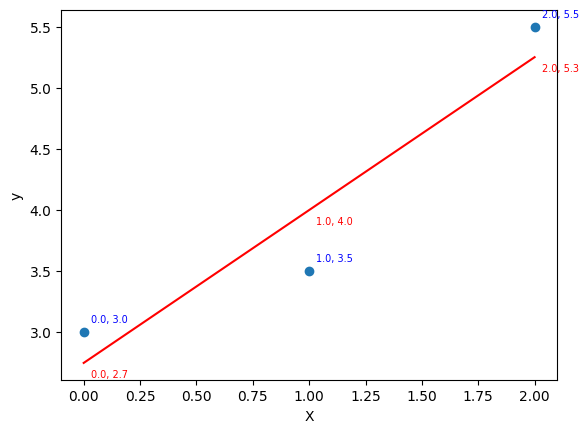

In [7]:
plt.scatter( X, y )
# 실제값 산점도

plt.plot(
    X, y_prediction,
    # [min(X), max(X)],
    # [min(y_prediction), max(y_prediction)],
    color = "red"
)
# 학습된 예측값 회귀선

for x_i, y_i in zip(X, y):
    plt.annotate(
        f"{x_i:.1f}, {y_i:.1f}",
        (x_i, y_i),
        textcoords = "offset points",
        xytext = (5, 7),
        fontsize = 7,
        color = "blue")
for x_i, yp_i in zip(X, y_prediction):
    plt.annotate(
        f"{x_i:.1f}, {yp_i:.1f}",
        (x_i, yp_i),
        textcoords = "offset points",
        xytext = (5, -10),
        fontsize = 7,
        color = "red")
# 좌표 표시

plt.xlabel("X")
# x축 라벨
plt.ylabel("y")
# y축 라벨
plt.show()